# 📈 Módulo de Regresión de Precios con LSTM Regressor

**Arquitectura:** `LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(16, relu) → Dense(1, linear)`

**Tickers analizados:** FSM, VOLCABC1.LM, ABX.TO, BVN, BHP  
**Ventana de entrada:** 60 días (fija)  
**Horizontes de predicción:** 7, 14, 30 y 60 días  
**Métricas:** RMSE (USD), RMSE (%), MAE, R²  

---
> ⚠️ **Nota:** Ejecutar en Google Colab con GPU activada (Entorno de ejecución → Cambiar tipo de entorno → T4 GPU)

## 📦 Sección 1 — Instalación e Importación de Librerías

In [ ]:
# Instalar librerías necesarias
!pip install yfinance --quiet
!pip install pmdarima --quiet  # Para el modelo ARIMA opcional

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 35.7 MB/s eta 0:00:00


In [ ]:
# ─── Librerías estándar ───────────────────────────────────────────────────────
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# ─── Descarga de datos ───────────────────────────────────────────────────────
import yfinance as yf

# ─── Preprocesamiento ────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ─── Deep Learning ───────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ─── ARIMA opcional ──────────────────────────────────────────────────────────
try:
    from pmdarima import auto_arima
    ARIMA_DISPONIBLE = True
except ImportError:
    ARIMA_DISPONIBLE = False

warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow versión: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"ARIMA disponible: {ARIMA_DISPONIBLE}")

TensorFlow versión: 2.20.0
GPU disponible: True
ARIMA disponible: True


## ⚙️ Sección 2 — Configuración Global

In [ ]:
# ─── Parámetros del modelo (NO modificar la ventana) ─────────────────────────

# Tickers a analizar
TICKERS = ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']

# Ventana de entrada FIJA (no modificable)
VENTANA = 60  # días

# Horizontes de predicción futura
HORIZONTES = [7, 14, 30, 60]  # días

# Parámetros de entrenamiento
EPOCAS       = 100
BATCH_SIZE   = 32
LEARNING_RATE = 0.001
VALIDACION   = 0.1   # 10% de datos para validación durante entrenamiento
TEST_SPLIT   = 0.15  # 15% de datos para test final

# Intervalo de fechas para descarga (5 años de historia)
FECHA_FIN    = datetime.today().strftime('%Y-%m-%d')
FECHA_INICIO = (datetime.today() - timedelta(days=365 * 5)).strftime('%Y-%m-%d')

# Nivel de confianza para las bandas (95%)
Z_CONFIANZA = 1.96

print("Configuración cargada correctamente.")
print(f"  Período: {FECHA_INICIO} → {FECHA_FIN}")
print(f"  Ventana de entrada: {VENTANA} días")
print(f"  Horizontes: {HORIZONTES} días")
print(f"  Épocas / Batch: {EPOCAS} / {BATCH_SIZE}")

Configuración cargada correctamente.
  Período: 2021-06-16 → 2026-06-15
  Ventana de entrada: 60 días
  Horizontes: [7, 14, 30, 60] días
  Épocas / Batch: 100 / 32


## 📥 Sección 3 — Descarga de Datos desde Yahoo Finance

In [ ]:
def descargar_datos(tickers, fecha_inicio, fecha_fin):
    """
    Descarga datos de cierre ajustado para cada ticker desde Yahoo Finance.
    Retorna un diccionario {ticker: Series} con los precios de cierre.
    """
    datos = {}
    for ticker in tickers:
        print(f"  Descargando {ticker}...", end=" ")
        try:
            df = yf.download(ticker, start=fecha_inicio, end=fecha_fin,
                             auto_adjust=True, progress=False)
            if df.empty or len(df) < VENTANA * 2:
                print(f"⚠ Sin datos suficientes (filas: {len(df)})")
                continue
            # Usar columna Close (precio ajustado)
            serie = df['Close'].dropna()
            if hasattr(serie.columns, '__iter__'):
                # yfinance a veces retorna MultiIndex
                serie = serie.iloc[:, 0]
            datos[ticker] = serie
            print(f"✓ {len(serie)} registros | Último precio: ${serie.iloc[-1]:.2f}")
        except Exception as e:
            print(f"✗ Error: {e}")
    return datos


print("Descargando datos de Yahoo Finance...")
datos_raw = descargar_datos(TICKERS, FECHA_INICIO, FECHA_FIN)
print(f"\nTickers con datos válidos: {list(datos_raw.keys())}")

Descargando datos de Yahoo Finance...
  Descargando FSM... ✓ 1254 registros | Último precio: $8.93
  Descargando VOLCABC1.LM... ✓ 1244 registros | Último precio: $0.84
  Descargando ABX.TO... ✓ 1253 registros | Último precio: $56.25
  Descargando BVN... ✓ 1254 registros | Último precio: $33.42
  Descargando BHP... ✓ 1254 registros | Último precio: $90.82

Tickers con datos válidos: ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']


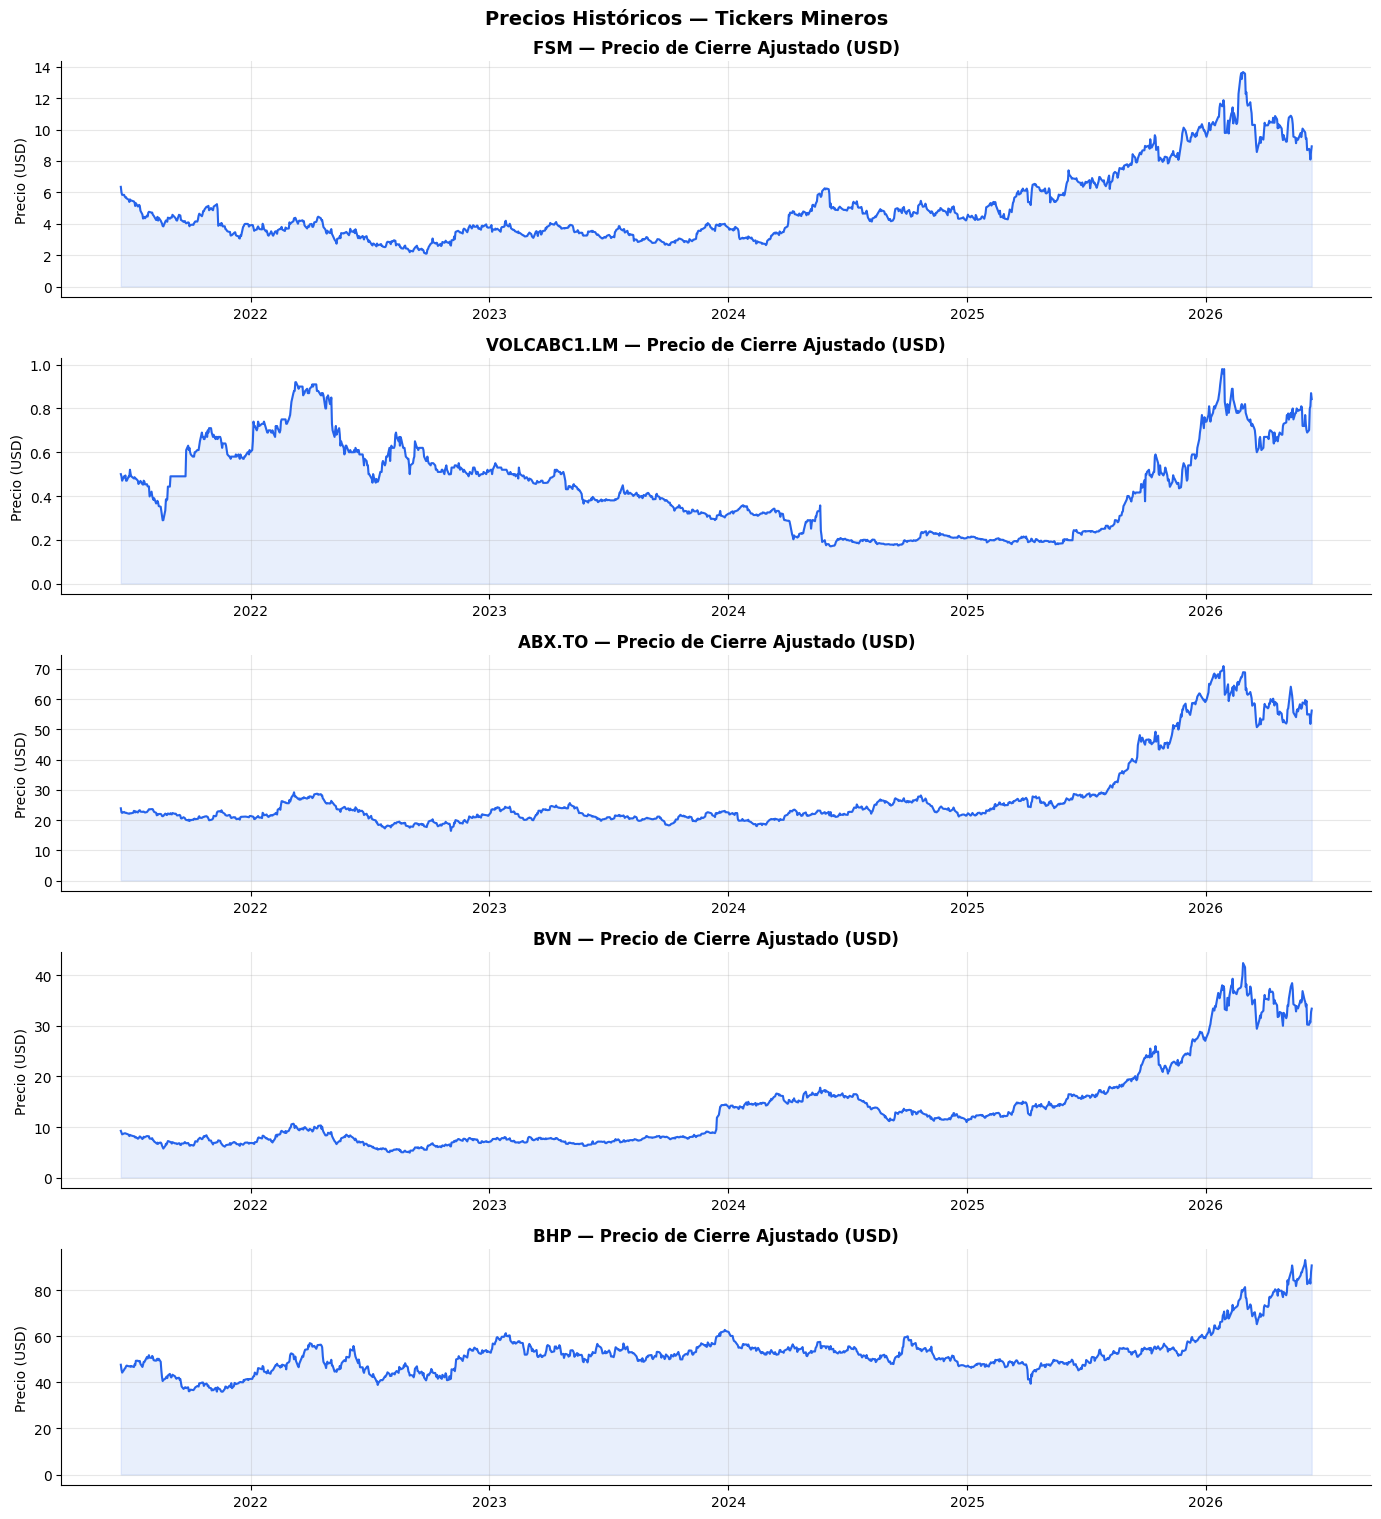

Gráfico guardado: precios_historicos.png


In [ ]:
# Visualizar precios históricos de todos los tickers
fig, axes = plt.subplots(len(datos_raw), 1, figsize=(14, 3 * len(datos_raw)))
if len(datos_raw) == 1:
    axes = [axes]

for ax, (ticker, serie) in zip(axes, datos_raw.items()):
    ax.plot(serie.index, serie.values, linewidth=1.5, color='#2563EB')
    ax.fill_between(serie.index, serie.values, alpha=0.1, color='#2563EB')
    ax.set_title(f'{ticker} — Precio de Cierre Ajustado (USD)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Precio (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.suptitle('Precios Históricos — Tickers Mineros', fontsize=14, y=1.01, fontweight='bold')
plt.savefig('precios_historicos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: precios_historicos.png")

## 🔧 Sección 4 — Preprocesamiento y Ventanas Deslizantes

In [ ]:
def crear_ventanas_deslizantes(serie_normalizada, ventana):
    """
    Crea ventanas deslizantes de longitud `ventana`.
    Cada muestra X[i] contiene `ventana` días consecutivos.
    Cada etiqueta y[i] contiene el precio del día siguiente.

    Retorna:
        X : array de forma (n_muestras, ventana, 1)
        y : array de forma (n_muestras,)
    """
    X, y = [], []
    for i in range(ventana, len(serie_normalizada)):
        # Ventana de 60 días anteriores como entrada
        X.append(serie_normalizada[i - ventana:i, 0])
        # Precio del día siguiente como objetivo
        y.append(serie_normalizada[i, 0])
    return np.array(X).reshape(-1, ventana, 1), np.array(y)


def preprocesar_ticker(serie, ventana, test_split):
    """
    Normaliza la serie con MinMaxScaler y divide en train/test.
    La ventana de 60 días es FIJA y no puede ser modificada.

    Retorna:
        X_train, y_train, X_test, y_test : conjuntos de datos
        scaler                           : el escalador ajustado
        precios_originales               : valores sin escalar
    """
    valores = serie.values.reshape(-1, 1)

    # Índice de corte train/test ANTES de crear ventanas
    corte = int(len(valores) * (1 - test_split))

    # Ajustar scaler SOLO con datos de entrenamiento (evitar fuga de datos)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(valores[:corte])

    # Normalizar toda la serie con el scaler de entrenamiento
    valores_norm = scaler.transform(valores)

    # Crear ventanas sobre la serie completa normalizada
    X_all, y_all = crear_ventanas_deslizantes(valores_norm, ventana)

    # Ajustar índice de corte considerando las ventanas
    corte_ventanas = corte - ventana

    X_train = X_all[:corte_ventanas]
    y_train = y_all[:corte_ventanas]
    X_test  = X_all[corte_ventanas:]
    y_test  = y_all[corte_ventanas:]

    return X_train, y_train, X_test, y_test, scaler, valores


print("Funciones de preprocesamiento definidas.")
print(f"  Ventana fija: {VENTANA} días")
print(f"  Normalización: MinMaxScaler(0, 1) ajustado solo en train")

Funciones de preprocesamiento definidas.
  Ventana fija: 60 días
  Normalización: MinMaxScaler(0, 1) ajustado solo en train


## 🧠 Sección 5 — Construcción del Modelo LSTM Regressor

In [ ]:
def construir_modelo_lstm(ventana, lr=0.001):
    """
    Construye el modelo LSTM Regressor con la arquitectura especificada:
        LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2)
                 → Dense(16, relu) → Dense(1, linear)

    Parámetros:
        ventana (int): número de pasos temporales de entrada (60, fijo)
        lr (float)   : tasa de aprendizaje del optimizador Adam

    Retorna:
        modelo compilado de Keras
    """
    modelo = Sequential(name='LSTM_Regressor_Precios', layers=[
        # Capa LSTM 1 — captura dependencias largas de la serie temporal
        LSTM(64,
             return_sequences=True,   # Necesario para apilar otra capa LSTM
             input_shape=(ventana, 1),
             name='lstm_64'),
        # Regularización para prevenir sobreajuste
        Dropout(0.2, name='dropout_1'),

        # Capa LSTM 2 — extrae patrones de más alto nivel
        LSTM(32,
             return_sequences=False,  # Última capa LSTM devuelve vector
             name='lstm_32'),
        Dropout(0.2, name='dropout_2'),

        # Capa densa intermedia — combina características aprendidas
        Dense(16, activation='relu', name='dense_16'),

        # Capa de salida — predicción de precio continuo (sin activación)
        Dense(1, activation='linear', name='output_precio'),
    ])

    # Compilar con Adam y función de pérdida MSE para regresión
    modelo.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return modelo


# Mostrar arquitectura del modelo
modelo_demo = construir_modelo_lstm(VENTANA)
modelo_demo.summary()
print(f"\nParámetros totales: {modelo_demo.count_params():,}")

Model: "LSTM_Regressor_Precios"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_64 (LSTM)                  │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_precio (Dense)           │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


Parámetros totales: 29,857


## 🏋️ Sección 6 — Entrenamiento del Modelo

In [ ]:
def entrenar_modelo(modelo, X_train, y_train, epocas, batch_size, validacion):
    """
    Entrena el modelo LSTM con callbacks de parada temprana y
    reducción de tasa de aprendizaje para mejorar la convergencia.

    Parámetros:
        modelo     : modelo Keras a entrenar
        X_train    : ventanas de entrenamiento (n, 60, 1)
        y_train    : precios objetivo normalizados
        epocas     : número máximo de épocas (100)
        batch_size : tamaño del lote (32)
        validacion : fracción de datos para validación interna

    Retorna:
        history : historial de entrenamiento
    """
    callbacks = [
        # Parada temprana si val_loss no mejora en 15 épocas
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        # Reducir LR a la mitad si val_loss no mejora en 7 épocas
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = modelo.fit(
        X_train, y_train,
        epochs=epocas,
        batch_size=batch_size,
        validation_split=validacion,
        callbacks=callbacks,
        verbose=1
    )
    return history


def graficar_historia(history, ticker):
    """Grafica la curva de pérdida de entrenamiento y validación."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    epocas_reales = range(1, len(history.history['loss']) + 1)

    # Pérdida MSE
    ax1.plot(epocas_reales, history.history['loss'],     label='Train Loss', color='#2563EB')
    ax1.plot(epocas_reales, history.history['val_loss'], label='Val Loss',   color='#DC2626', linestyle='--')
    ax1.set_title(f'{ticker} — Pérdida MSE')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('MSE')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.spines[['top', 'right']].set_visible(False)

    # MAE
    ax2.plot(epocas_reales, history.history['mae'],     label='Train MAE', color='#059669')
    ax2.plot(epocas_reales, history.history['val_mae'], label='Val MAE',   color='#D97706', linestyle='--')
    ax2.set_title(f'{ticker} — Error Absoluto Medio')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('MAE')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.spines[['top', 'right']].set_visible(False)

    plt.suptitle(f'Historial de Entrenamiento — {ticker}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'historia_{ticker.replace(".", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


print("Funciones de entrenamiento definidas.")

Funciones de entrenamiento definidas.


## 📊 Sección 7 — Métricas y Predicciones

In [ ]:
def calcular_metricas(y_real, y_pred, scaler):
    """
    Calcula RMSE (USD), RMSE (%), MAE y R² desnormalizando primero las predicciones.

    Retorna:
        dict con métricas en escala real (USD)
    """
    # Desnormalizar para obtener precios en USD
    y_real_usd = scaler.inverse_transform(y_real.reshape(-1, 1)).flatten()
    y_pred_usd = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    rmse_usd   = np.sqrt(mean_squared_error(y_real_usd, y_pred_usd))
    precio_med = np.mean(y_real_usd)
    rmse_pct   = (rmse_usd / precio_med) * 100 if precio_med != 0 else 0
    mae_usd    = mean_absolute_error(y_real_usd, y_pred_usd)
    r2         = r2_score(y_real_usd, y_pred_usd)

    return {
        'rmse_usd'  : round(rmse_usd, 4),
        'rmse_pct'  : round(rmse_pct, 4),
        'mae_usd'   : round(mae_usd, 4),
        'r2'        : round(r2, 6),
        'precio_med': round(precio_med, 4),
        'y_real_usd': y_real_usd.tolist(),
        'y_pred_usd': y_pred_usd.tolist(),
    }


def predecir_horizonte(modelo, serie_norm, ventana, horizonte, scaler):
    """
    Predicción multi-paso iterativa: usa las predicciones anteriores
    como entrada para predecir el siguiente paso.

    Parámetros:
        modelo       : modelo LSTM entrenado
        serie_norm   : serie completa normalizada (n, 1)
        ventana      : tamaño de ventana (60, fijo)
        horizonte    : días a predecir en el futuro
        scaler       : MinMaxScaler ajustado en entrenamiento

    Retorna:
        predicciones_usd : lista de precios predichos en USD
        bandas_inf       : banda inferior (±1.96 * RMSE)
        bandas_sup       : banda superior (±1.96 * RMSE)
    """
    # Tomar la última ventana de la serie para iniciar la predicción
    ventana_actual = serie_norm[-ventana:].copy().tolist()
    predicciones_norm = []

    for _ in range(horizonte):
        # Preparar entrada con forma (1, ventana, 1)
        entrada = np.array(ventana_actual[-ventana:]).reshape(1, ventana, 1)
        # Predecir siguiente valor
        pred = modelo.predict(entrada, verbose=0)[0, 0]
        predicciones_norm.append(pred)
        # Agregar predicción a la ventana para el siguiente paso
        ventana_actual.append([pred])

    # Desnormalizar predicciones
    preds_array = np.array(predicciones_norm).reshape(-1, 1)
    predicciones_usd = scaler.inverse_transform(preds_array).flatten().tolist()

    return predicciones_usd


def calcular_bandas(predicciones_usd, rmse_usd, z=1.96):
    """
    Calcula bandas de confianza del 95%: pred ± z * RMSE.
    El error crece con el horizonte (incertidumbre acumulada).
    """
    bandas_inf, bandas_sup = [], []
    for i, pred in enumerate(predicciones_usd):
        # El error se expande con la raíz del horizonte (random walk assumption)
        error = z * rmse_usd * np.sqrt(i + 1)
        bandas_inf.append(round(pred - error, 4))
        bandas_sup.append(round(pred + error, 4))
    return bandas_inf, bandas_sup


print("Funciones de métricas y predicción definidas.")

Funciones de métricas y predicción definidas.


In [ ]:
def graficar_predicciones_test(ticker, fechas_test, y_real_usd, y_pred_usd, rmse_usd):
    """Grafica real vs predicho en el conjunto de test con bandas de confianza."""
    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(fechas_test, y_real_usd, label='Precio Real',    color='#1e3a5f', linewidth=1.5)
    ax.plot(fechas_test, y_pred_usd, label='LSTM Predicho',  color='#EF4444', linewidth=1.5, linestyle='--')

    # Bandas de confianza constantes (±1.96 * RMSE) sobre el conjunto de test
    banda_sup = [p + 1.96 * rmse_usd for p in y_pred_usd]
    banda_inf = [p - 1.96 * rmse_usd for p in y_pred_usd]
    ax.fill_between(fechas_test, banda_inf, banda_sup, alpha=0.15, color='#EF4444', label='IC 95%')

    ax.set_title(f'{ticker} — Predicción vs Real (Test Set)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Precio (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f'prediccion_test_{ticker.replace(".", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


def graficar_horizonte_futuro(ticker, precios_hist, fecha_ultimo, horizontes_pred, horizontes_dias):
    """Grafica las predicciones futuras con bandas de confianza expandibles."""
    fig, ax = plt.subplots(figsize=(13, 5))

    # Mostrar últimos 90 días de historia
    hist_reciente = precios_hist[-90:]
    fechas_hist   = pd.date_range(end=fecha_ultimo, periods=len(hist_reciente), freq='B')
    ax.plot(fechas_hist, hist_reciente, color='#1e3a5f', linewidth=1.5, label='Histórico')

    # Colores para cada horizonte
    colores = ['#10B981', '#F59E0B', '#EF4444', '#8B5CF6']

    for (dias, preds_info), color in zip(horizontes_pred.items(), colores):
        fechas_fut = pd.date_range(
            start=fecha_ultimo + timedelta(days=1),
            periods=dias, freq='B'
        )[:len(preds_info['predicciones'])]

        preds     = preds_info['predicciones']
        b_inf     = preds_info['banda_inf']
        b_sup     = preds_info['banda_sup']
        n_pts     = min(len(fechas_fut), len(preds))

        ax.plot(fechas_fut[:n_pts], preds[:n_pts], color=color, linewidth=2,
                linestyle='--', label=f'+{dias}d')
        ax.fill_between(fechas_fut[:n_pts], b_inf[:n_pts], b_sup[:n_pts],
                        alpha=0.15, color=color)

    # Línea vertical en el inicio de predicción
    ax.axvline(x=fecha_ultimo, color='gray', linestyle=':', linewidth=1.5, label='Hoy')

    ax.set_title(f'{ticker} — Predicción Futura con Bandas de Confianza IC 95%',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Precio (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f'horizonte_{ticker.replace(".", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


print("Funciones de visualización definidas.")

Funciones de visualización definidas.


## 🔄 Sección 8 — Pipeline Principal: Entrena y Evalúa cada Ticker


  PROCESANDO: FSM
  Train: (1005, 60, 1) | Test: (189, 60, 1)

  Entrenando 100 épocas (batch=32)...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0408 - mae: 0.1551 - val_loss: 0.0931 - val_mae: 0.2939 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0077 - mae: 0.0688 - val_loss: 0.0236 - val_mae: 0.1367 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0051 - mae: 0.0561 - val_loss: 0.0047 - val_mae: 0.0524 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0044 - mae: 0.0518 - val_loss: 0.0046 - val_mae: 0.0519 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0043 - mae: 0.0509 - val_loss: 0.0043 - val_mae: 0.0506 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0039 - mae: 0.0479 - val_loss: 0.0059 - val_mae: 0.0603 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms

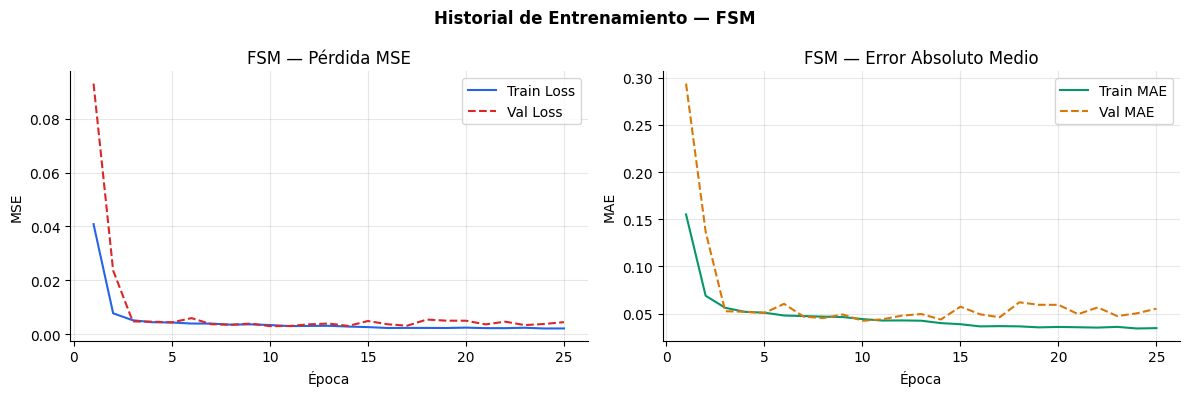


  ─── Métricas en Test Set ───
  RMSE (USD) : $0.9618
  RMSE (%)   : 9.83%
  MAE  (USD) : $0.7322
  R²         : 0.3823
  Precio med : $9.7848


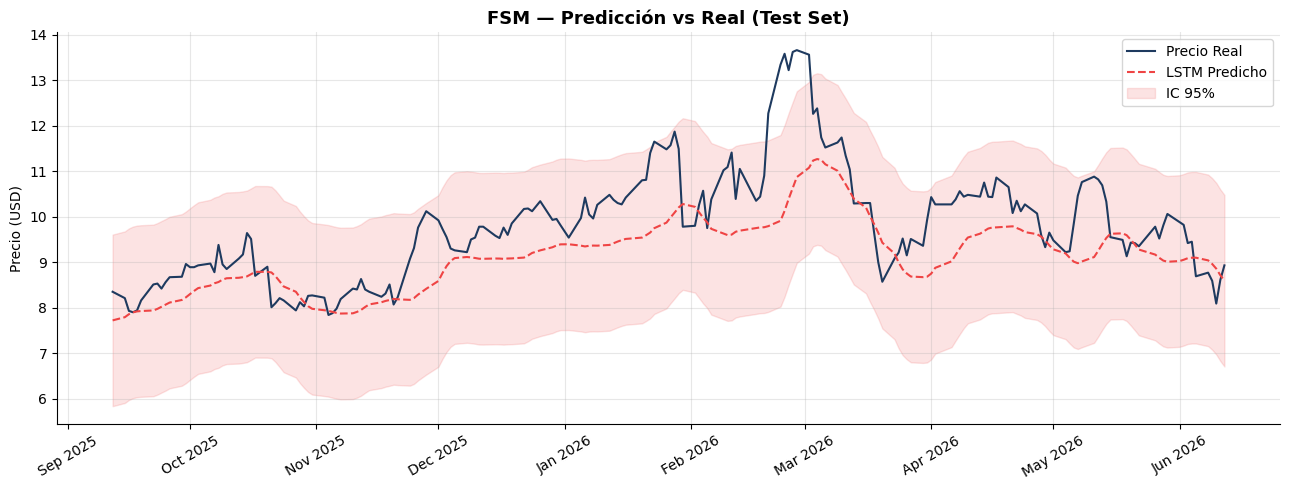


  ─── Predicciones Futuras ───
  + 7d → Precio final: $8.14 (IC 95%: $3.15 – $13.12)
  +14d → Precio final: $7.91 (IC 95%: $0.85 – $14.96)
  +30d → Precio final: $7.60 (IC 95%: $-2.73 – $17.93)
  +60d → Precio final: $7.34 (IC 95%: $-7.26 – $21.94)


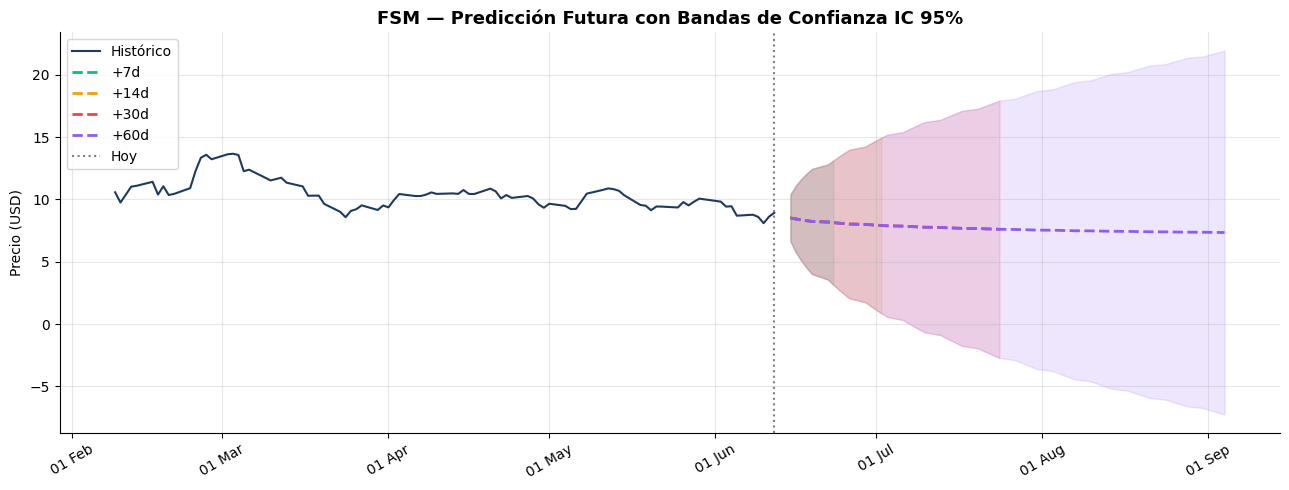


  PROCESANDO: VOLCABC1.LM
  Train: (997, 60, 1) | Test: (187, 60, 1)

  Entrenando 100 épocas (batch=32)...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0318 - mae: 0.1240 - val_loss: 0.0023 - val_mae: 0.0440 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0057 - mae: 0.0540 - val_loss: 0.0024 - val_mae: 0.0356 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0051 - mae: 0.0490 - val_loss: 0.0015 - val_mae: 0.0255 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0042 - mae: 0.0437 - val_loss: 0.0017 - val_mae: 0.0282 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0039 - mae: 0.0428 - val_loss: 0.0016 - val_mae: 0.0265 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0039 - mae: 0.0422 - val_loss: 0.0012 - val_mae: 0.0221 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 

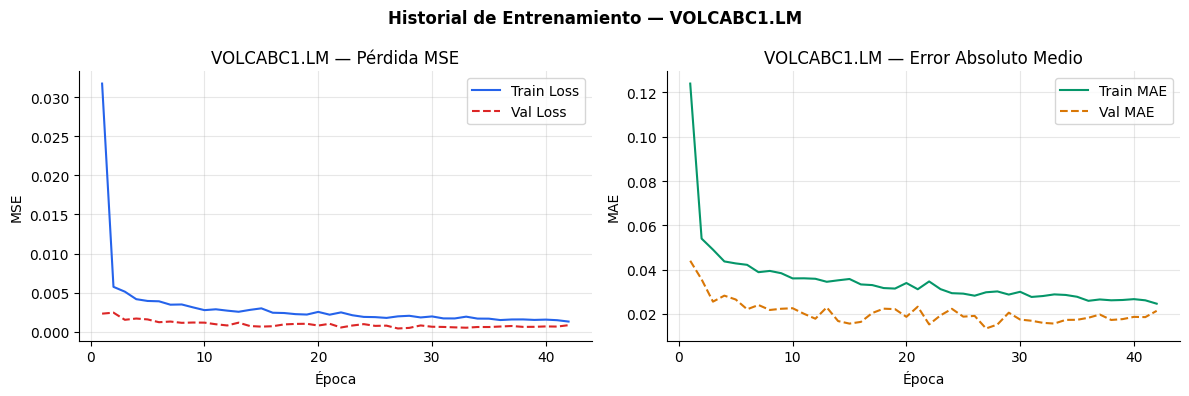


  ─── Métricas en Test Set ───
  RMSE (USD) : $0.0515
  RMSE (%)   : 7.81%
  MAE  (USD) : $0.0394
  R²         : 0.8720
  Precio med : $0.6602


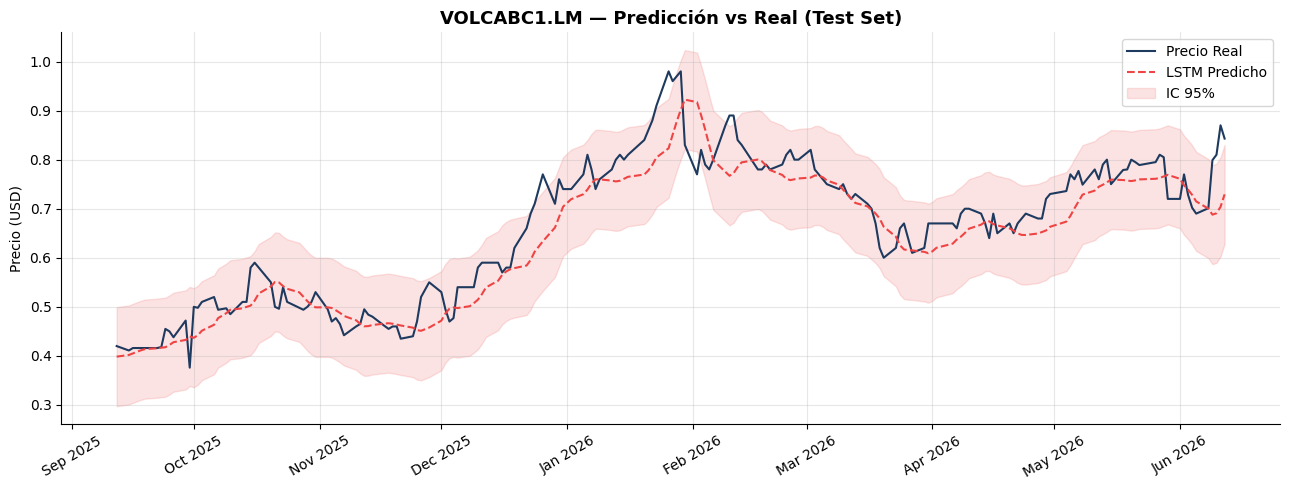


  ─── Predicciones Futuras ───
  + 7d → Precio final: $0.76 (IC 95%: $0.49 – $1.02)
  +14d → Precio final: $0.70 (IC 95%: $0.32 – $1.07)
  +30d → Precio final: $0.59 (IC 95%: $0.04 – $1.14)
  +60d → Precio final: $0.51 (IC 95%: $-0.27 – $1.29)


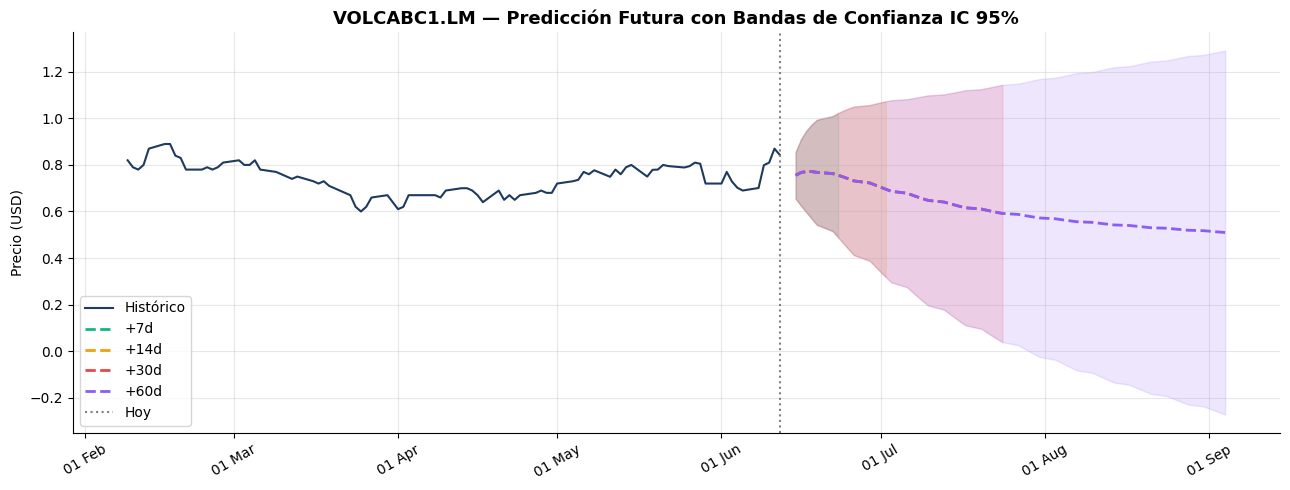


  PROCESANDO: ABX.TO
  Train: (1005, 60, 1) | Test: (188, 60, 1)

  Entrenando 100 épocas (batch=32)...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0117 - mae: 0.0785 - val_loss: 0.0151 - val_mae: 0.0886 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0038 - mae: 0.0488 - val_loss: 0.0130 - val_mae: 0.0903 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0029 - mae: 0.0422 - val_loss: 0.0043 - val_mae: 0.0504 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025 - mae: 0.0386 - val_loss: 0.0053 - val_mae: 0.0582 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0024 - mae: 0.0382 - val_loss: 0.0027 - val_mae: 0.0407 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0023 - mae: 0.0371 - val_loss: 0.0040 - val_mae: 0.0512 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1

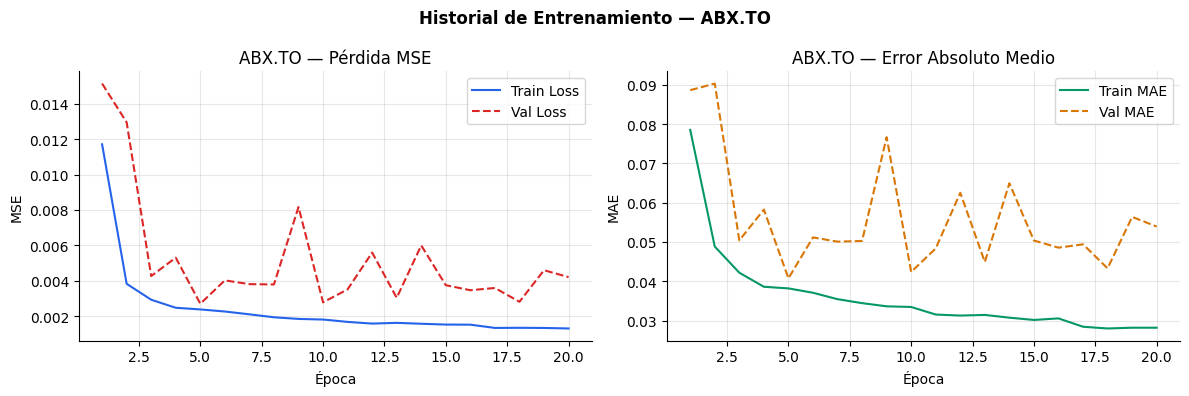


  ─── Métricas en Test Set ───
  RMSE (USD) : $5.0440
  RMSE (%)   : 8.97%
  MAE  (USD) : $4.1199
  R²         : 0.5409
  Precio med : $56.2429


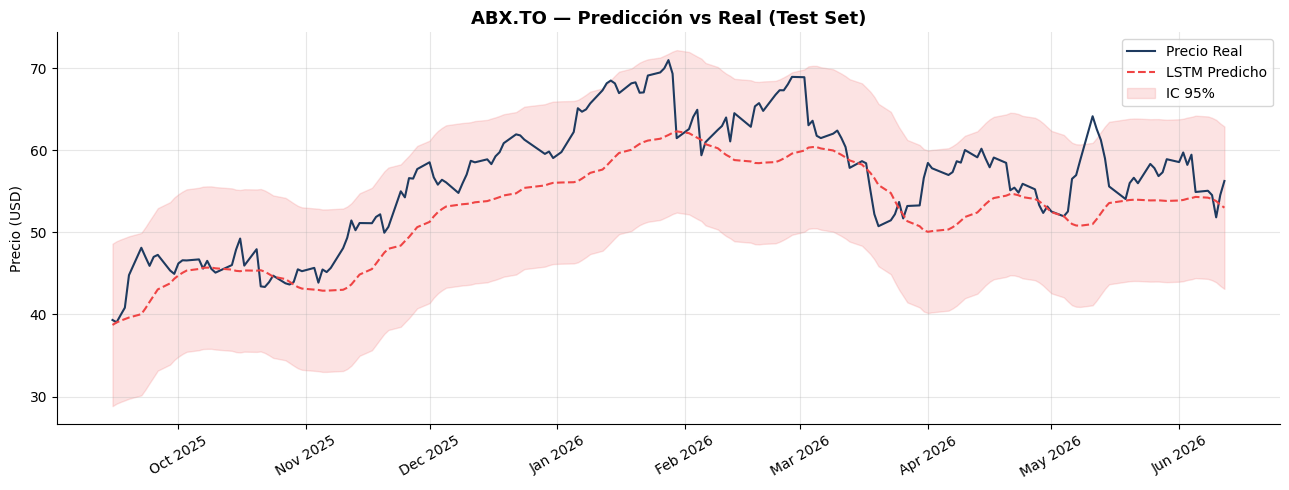


  ─── Predicciones Futuras ───
  + 7d → Precio final: $50.01 (IC 95%: $23.86 – $76.17)
  +14d → Precio final: $46.63 (IC 95%: $9.64 – $83.62)
  +30d → Precio final: $40.21 (IC 95%: $-13.94 – $94.35)
  +60d → Precio final: $33.88 (IC 95%: $-42.70 – $110.46)


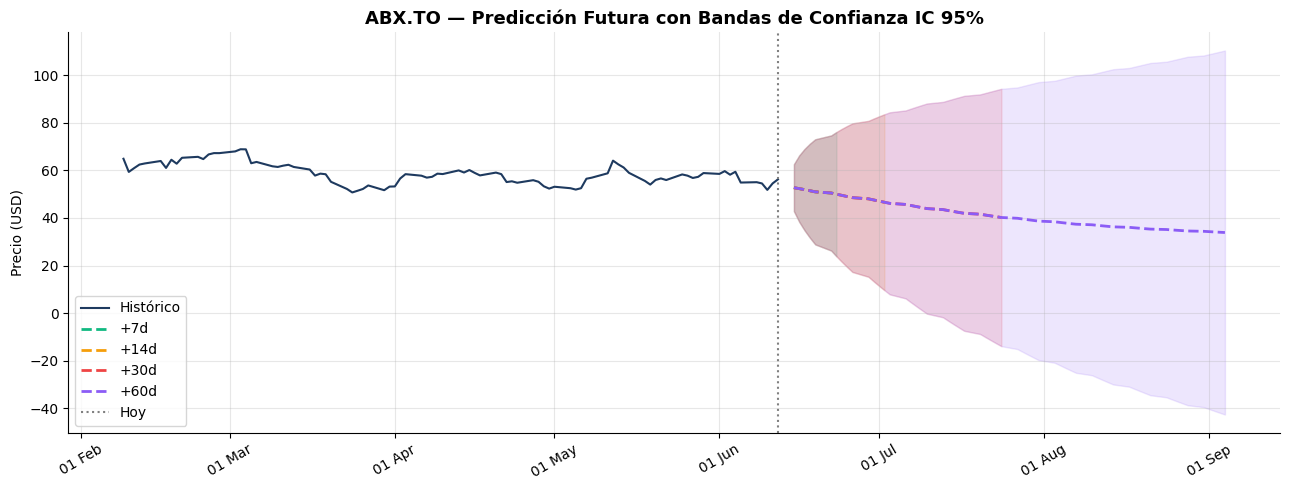


  PROCESANDO: BVN
  Train: (1005, 60, 1) | Test: (189, 60, 1)

  Entrenando 100 épocas (batch=32)...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0223 - mae: 0.1022 - val_loss: 0.0081 - val_mae: 0.0768 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0049 - mae: 0.0487 - val_loss: 0.0095 - val_mae: 0.0877 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0047 - mae: 0.0483 - val_loss: 0.0133 - val_mae: 0.1069 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0043 - mae: 0.0458 - val_loss: 0.0116 - val_mae: 0.0985 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0042 - mae: 0.0460 - val_loss: 0.0080 - val_mae: 0.0797 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0036 - mae: 0.0426 - val_loss: 0.0104 - val_mae: 0.0930 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms

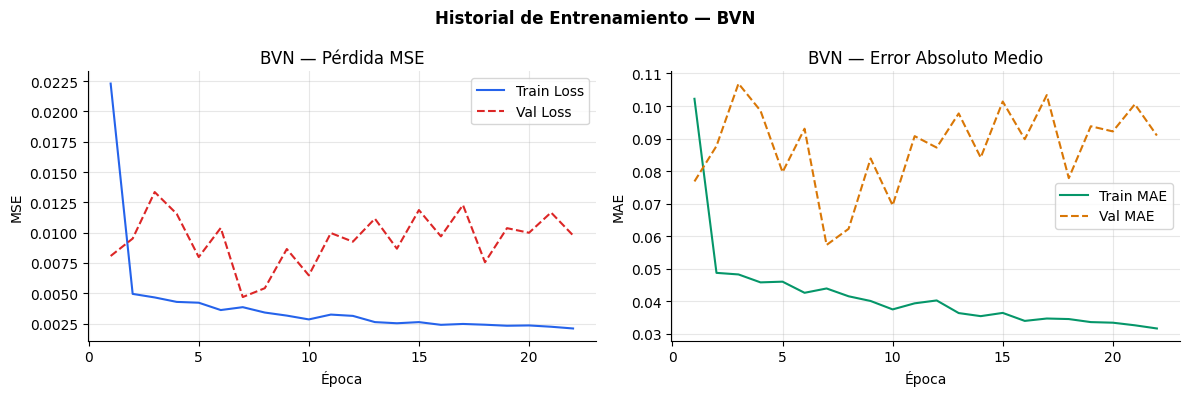


  ─── Métricas en Test Set ───
  RMSE (USD) : $6.7857
  RMSE (%)   : 22.47%
  MAE  (USD) : $5.9776
  R²         : -0.2882
  Precio med : $30.2007


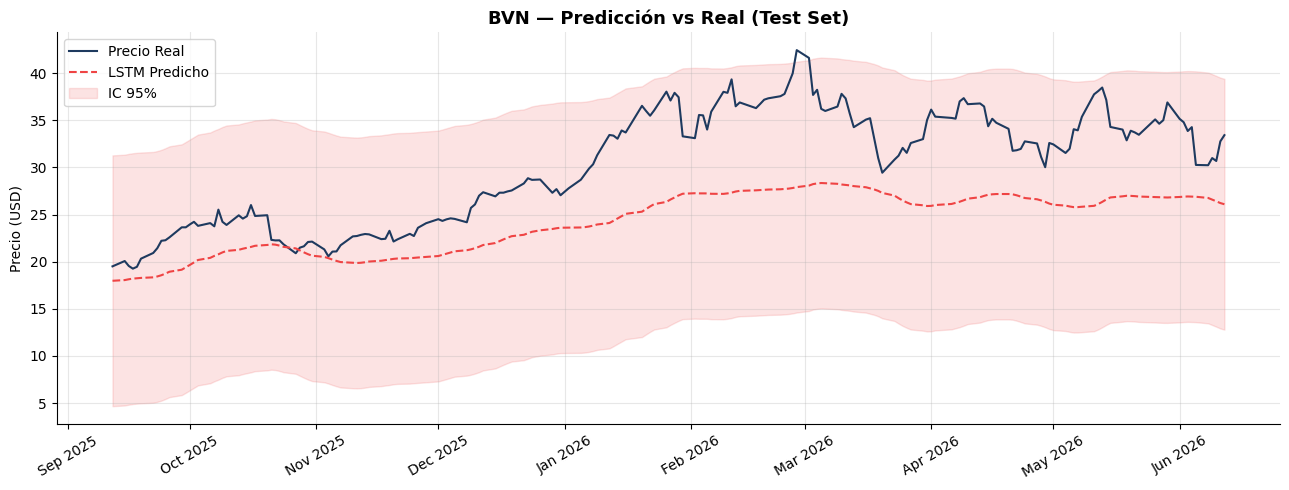


  ─── Predicciones Futuras ───
  + 7d → Precio final: $23.90 (IC 95%: $-11.29 – $59.09)
  +14d → Precio final: $21.39 (IC 95%: $-28.38 – $71.15)
  +30d → Precio final: $17.99 (IC 95%: $-54.86 – $90.84)
  +60d → Precio final: $15.39 (IC 95%: $-87.63 – $118.42)


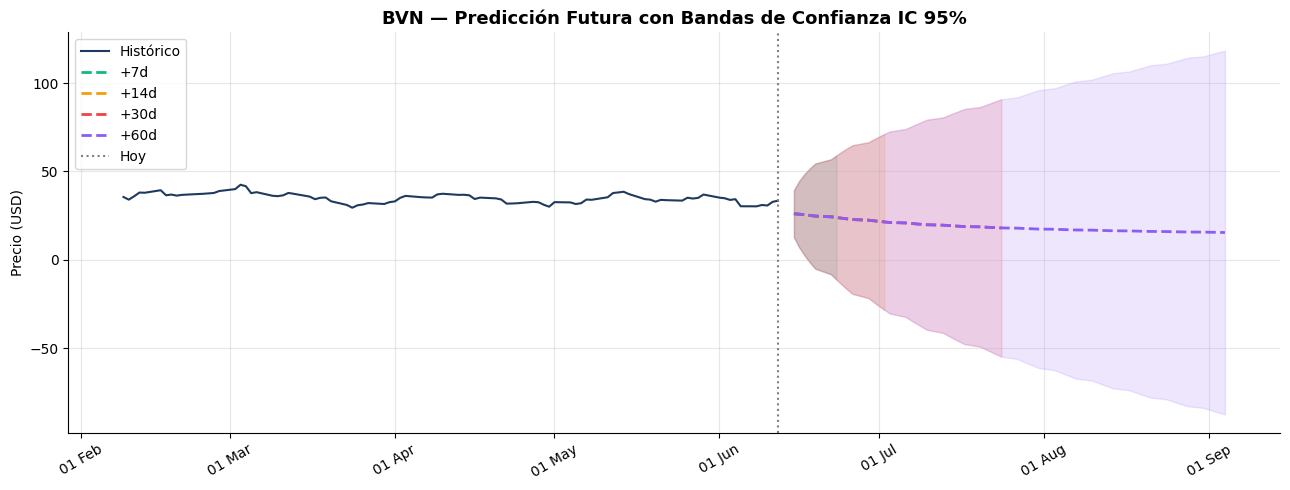


  PROCESANDO: BHP
  Train: (1005, 60, 1) | Test: (189, 60, 1)

  Entrenando 100 épocas (batch=32)...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1059 - mae: 0.2496 - val_loss: 0.0070 - val_mae: 0.0667 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0161 - mae: 0.1007 - val_loss: 0.0037 - val_mae: 0.0482 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0134 - mae: 0.0894 - val_loss: 0.0036 - val_mae: 0.0485 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0110 - mae: 0.0820 - val_loss: 0.0042 - val_mae: 0.0537 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0110 - mae: 0.0818 - val_loss: 0.0037 - val_mae: 0.0502 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0107 - mae: 0.0804 - val_loss: 0.0047 - val_mae: 0.0567 - learning_rate: 0.0010
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms

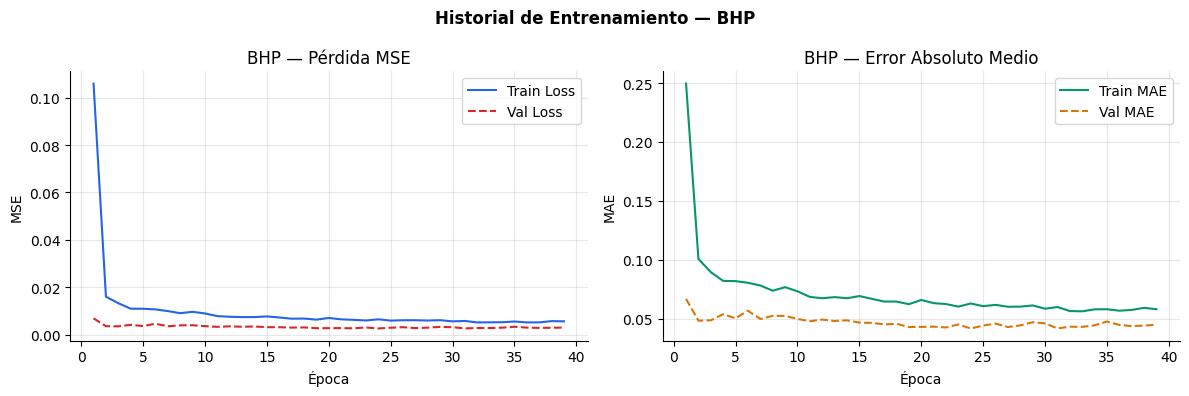


  ─── Métricas en Test Set ───
  RMSE (USD) : $5.8315
  RMSE (%)   : 8.67%
  MAE  (USD) : $4.3291
  R²         : 0.7589
  Precio med : $67.2724


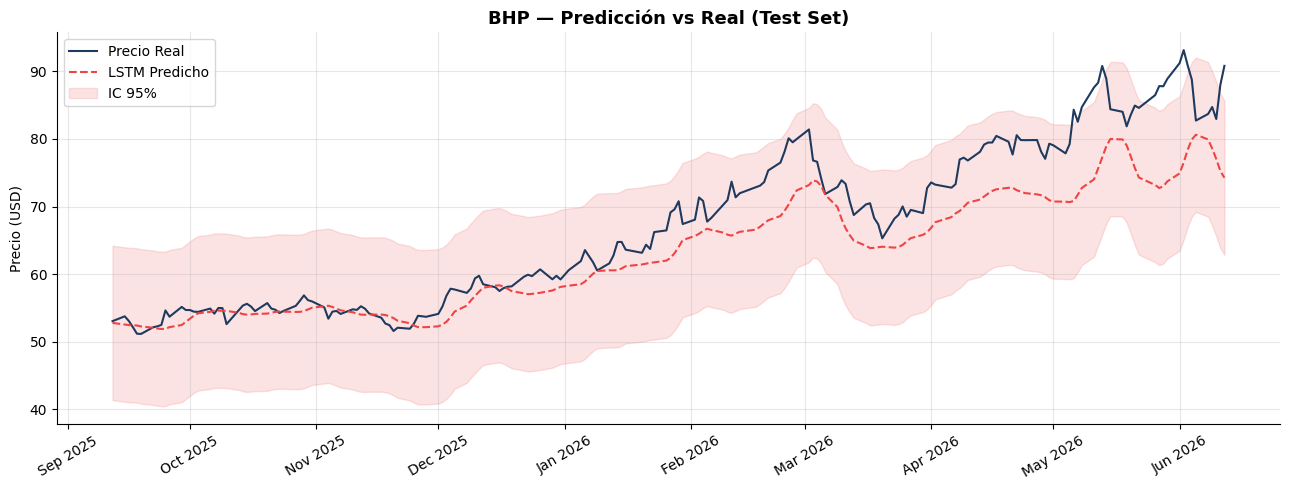


  ─── Predicciones Futuras ───
  + 7d → Precio final: $60.79 (IC 95%: $30.55 – $91.03)
  +14d → Precio final: $53.52 (IC 95%: $10.75 – $96.28)
  +30d → Precio final: $55.45 (IC 95%: $-7.15 – $118.05)
  +60d → Precio final: $52.57 (IC 95%: $-35.96 – $141.11)


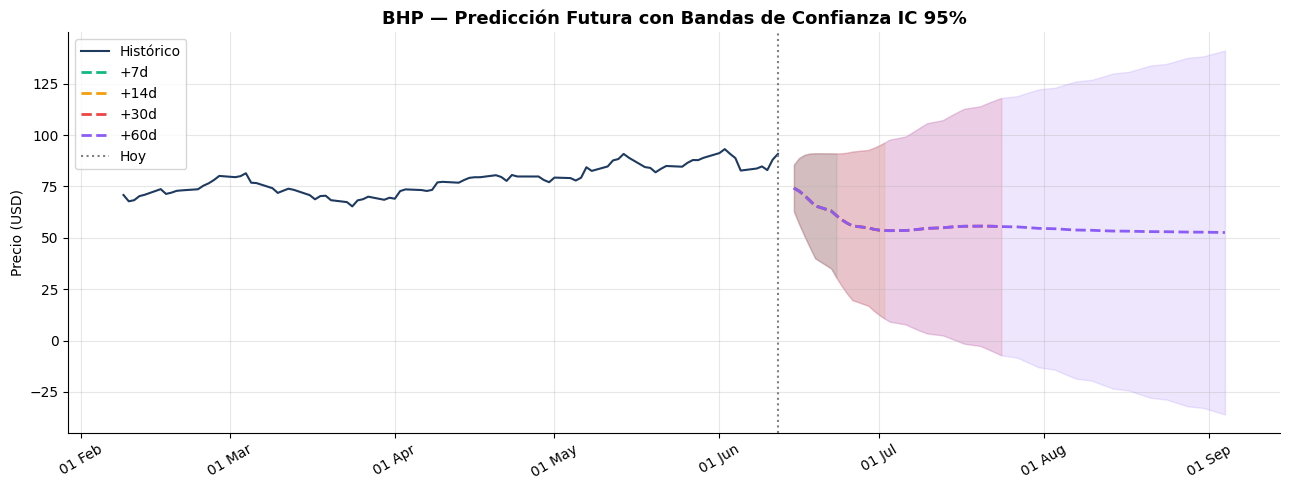


  ✅ PIPELINE COMPLETADO PARA TODOS LOS TICKERS


In [12]:
# Diccionario donde se almacenan todos los resultados para el JSON final
resultados_globales = {}

for ticker, serie in datos_raw.items():
    print("\n" + "="*65)
    print(f"  PROCESANDO: {ticker}")
    print("="*65)

    # ── 1. Preprocesar ──────────────────────────────────────────────
    X_train, y_train, X_test, y_test, scaler, valores = \
        preprocesar_ticker(serie, VENTANA, TEST_SPLIT)

    print(f"  Train: {X_train.shape} | Test: {X_test.shape}")

    # ── 2. Construir modelo ─────────────────────────────────────────
    modelo = construir_modelo_lstm(VENTANA, lr=LEARNING_RATE)

    # ── 3. Entrenar ──────────────────────────────────────────────────
    print(f"\n  Entrenando {EPOCAS} épocas (batch={BATCH_SIZE})...")
    history = entrenar_modelo(modelo, X_train, y_train,
                              EPOCAS, BATCH_SIZE, VALIDACION)

    # Graficar curvas de aprendizaje
    graficar_historia(history, ticker)

    # ── 4. Predecir sobre test ───────────────────────────────────────
    y_pred_test = modelo.predict(X_test, verbose=0).flatten()

    # ── 5. Calcular métricas ────────────────────────────────────────
    metricas = calcular_metricas(y_test, y_pred_test, scaler)

    print(f"\n  ─── Métricas en Test Set ───")
    print(f"  RMSE (USD) : ${metricas['rmse_usd']:.4f}")
    print(f"  RMSE (%)   : {metricas['rmse_pct']:.2f}%")
    print(f"  MAE  (USD) : ${metricas['mae_usd']:.4f}")
    print(f"  R²         : {metricas['r2']:.4f}")
    print(f"  Precio med : ${metricas['precio_med']:.4f}")

    # ── 6. Graficar real vs predicho en test ─────────────────────────
    n_test     = len(y_test)
    fechas_all = pd.to_datetime(serie.index)
    fechas_test_idx = fechas_all[-(n_test):]

    graficar_predicciones_test(
        ticker,
        fechas_test_idx,
        metricas['y_real_usd'],
        metricas['y_pred_usd'],
        metricas['rmse_usd']
    )

    # ── 7. Predicciones futuras por horizonte ────────────────────────
    serie_norm_completa = scaler.transform(valores)
    fecha_ultimo        = pd.to_datetime(serie.index[-1])
    horizontes_pred     = {}

    print("\n  ─── Predicciones Futuras ───")
    for h in HORIZONTES:
        preds_usd = predecir_horizonte(
            modelo, serie_norm_completa, VENTANA, h, scaler
        )
        b_inf, b_sup = calcular_bandas(preds_usd, metricas['rmse_usd'], Z_CONFIANZA)

        horizontes_pred[h] = {
            'predicciones': [round(p, 4) for p in preds_usd],
            'banda_inf'   : b_inf,
            'banda_sup'   : b_sup,
        }

        print(f"  +{h:2d}d → Precio final: ${preds_usd[-1]:.2f} "
              f"(IC 95%: ${b_inf[-1]:.2f} – ${b_sup[-1]:.2f})")

    # Graficar horizonte futuro
    graficar_horizonte_futuro(
        ticker, valores.flatten().tolist(),
        fecha_ultimo, horizontes_pred, HORIZONTES
    )

    # ── 8. Guardar resultados ────────────────────────────────────────
    resultados_globales[ticker] = {
        'metricas': {
            'rmse_usd'  : metricas['rmse_usd'],
            'rmse_pct'  : metricas['rmse_pct'],
            'mae_usd'   : metricas['mae_usd'],
            'r2'        : metricas['r2'],
            'precio_med': metricas['precio_med'],
        },
        'predicciones_futuras': {
            str(h): horizontes_pred[h] for h in HORIZONTES
        },
        'test_real' : metricas['y_real_usd'][-30:],  # Últimos 30 días de test
        'test_pred' : metricas['y_pred_usd'][-30:],
        'historico_fechas': [str(d.date()) for d in pd.to_datetime(serie.index)[-90:]],
        'historico_precios': serie.values[-90:].tolist(),
        'ultimo_precio': round(float(serie.iloc[-1]), 4),
        'fecha_ultimo' : str(fecha_ultimo.date()),
    }

    # Liberar memoria del modelo
    del modelo
    tf.keras.backend.clear_session()

print("\n" + "="*65)
print("  ✅ PIPELINE COMPLETADO PARA TODOS LOS TICKERS")
print("="*65)

## 📉 Sección 9 — Comparación Opcional con Modelo ARIMA

In [ ]:
# ─── Comparación con ARIMA (opcional) ────────────────────────────────────────
# Se ejecuta solo si pmdarima está disponible

resultados_arima = {}

if ARIMA_DISPONIBLE:
    print("Comparando LSTM vs ARIMA...\n")

    for ticker, serie in datos_raw.items():
        print(f"  ARIMA para {ticker}...", end=" ")
        try:
            valores = serie.values
            corte   = int(len(valores) * (1 - TEST_SPLIT))
            train_a = valores[:corte]
            test_a  = valores[corte:]

            # auto_arima selecciona p,d,q automáticamente
            modelo_arima = auto_arima(
                train_a,
                seasonal=False,
                stepwise=True,
                suppress_warnings=True,
                error_action='ignore',
                max_p=3, max_q=3
            )

            # Predicciones sobre el test set (one-step-ahead)
            preds_arima = modelo_arima.predict(n_periods=len(test_a))

            rmse_arima = np.sqrt(mean_squared_error(test_a, preds_arima))
            mae_arima  = mean_absolute_error(test_a, preds_arima)
            r2_arima   = r2_score(test_a, preds_arima)

            resultados_arima[ticker] = {
                'rmse_usd': round(rmse_arima, 4),
                'mae_usd' : round(mae_arima, 4),
                'r2'      : round(r2_arima, 6),
                'orden'   : str(modelo_arima.order),
            }

            print(f"✓ RMSE: ${rmse_arima:.4f} | R²: {r2_arima:.4f}")

        except Exception as e:
            print(f"✗ Error: {e}")

    # ── Tabla comparativa LSTM vs ARIMA ──────────────────────────────
    if resultados_arima:
        print("\n" + "─"*60)
        print(f"{'Ticker':<15} {'LSTM RMSE':>12} {'ARIMA RMSE':>12} {'LSTM R²':>10} {'ARIMA R²':>10} {'Mejor':>8}")
        print("─"*60)

        for ticker in resultados_arima:
            if ticker not in resultados_globales:
                continue
            r_lstm  = resultados_globales[ticker]['metricas']['rmse_usd']
            r_arima = resultados_arima[ticker]['rmse_usd']
            r2_lstm = resultados_globales[ticker]['metricas']['r2']
            r2_arm  = resultados_arima[ticker]['r2']
            mejor   = 'LSTM' if r_lstm < r_arima else 'ARIMA'

            print(f"{ticker:<15} {r_lstm:>11.4f}$ {r_arima:>11.4f}$ {r2_lstm:>10.4f} {r2_arm:>10.4f} {mejor:>8}")

        print("─"*60)

        # Agregar resultados ARIMA al resultado global para el JSON
        for ticker in resultados_arima:
            if ticker in resultados_globales:
                resultados_globales[ticker]['arima'] = resultados_arima[ticker]

else:
    print("⚠ pmdarima no disponible. Omitiendo comparación ARIMA.")
    print("  Para activarla ejecutar: !pip install pmdarima")

Comparando LSTM vs ARIMA...

  ARIMA para FSM... ✓ RMSE: $1.8257 | R²: -1.2257
  ARIMA para VOLCABC1.LM... ✓ RMSE: $0.3001 | R²: -3.3370
  ARIMA para ABX.TO... ✓ RMSE: $18.2800 | R²: -5.0298
  ARIMA para BVN... 

## 📋 Sección 10 — Tabla Resumen de Métricas

In [ ]:
# Construir tabla resumen
filas = []
for ticker, datos in resultados_globales.items():
    m = datos['metricas']
    filas.append({
        'Ticker'      : ticker,
        'Último precio': f"${datos['ultimo_precio']:.2f}",
        'RMSE (USD)'  : f"${m['rmse_usd']:.4f}",
        'RMSE (%)'    : f"{m['rmse_pct']:.2f}%",
        'MAE (USD)'   : f"${m['mae_usd']:.4f}",
        'R²'          : f"{m['r2']:.4f}",
    })
    # Predicciones de cada horizonte
    for h in HORIZONTES:
        h_str = str(h)
        if h_str in datos['predicciones_futuras']:
            pred = datos['predicciones_futuras'][h_str]['predicciones'][-1]
            filas[-1][f'+{h}d (USD)'] = f"${pred:.2f}"

df_resumen = pd.DataFrame(filas).set_index('Ticker')
print("\n══════════════════════════════════════════════════")
print("           RESUMEN FINAL — LSTM REGRESSOR")
print("══════════════════════════════════════════════════")
print(df_resumen.to_string())
print("══════════════════════════════════════════════════")

# Guardar tabla como CSV
df_resumen.to_csv('resumen_lstm_regressor.csv')
print("\nTabla guardada: resumen_lstm_regressor.csv")

## 💾 Sección 11 — Exportación a JSON para el Frontend

In [ ]:
# ─── Construir el payload JSON estructurado para el frontend ──────────────────

payload_json = {
    # Metadatos del modelo
    'modelo': {
        'tipo'           : 'LSTM Regressor',
        'arquitectura'   : 'LSTM(64)->Dropout(0.2)->LSTM(32)->Dropout(0.2)->Dense(16,relu)->Dense(1,linear)',
        'ventana_dias'   : VENTANA,
        'epocas'         : EPOCAS,
        'batch_size'     : BATCH_SIZE,
        'optimizador'    : 'Adam',
        'learning_rate'  : LEARNING_RATE,
        'nivel_confianza': '95% (±1.96 * RMSE)',
        'generado_en'    : datetime.now().isoformat(),
    },
    # Tickers procesados
    'tickers': list(resultados_globales.keys()),
    # Horizontes de predicción
    'horizontes_dias': HORIZONTES,
    # Resultados por ticker
    'resultados': {}
}

for ticker, datos in resultados_globales.items():
    payload_json['resultados'][ticker] = {
        # Último precio conocido
        'ultimo_precio' : datos['ultimo_precio'],
        'fecha_ultimo'  : datos['fecha_ultimo'],

        # Métricas de evaluación
        'metricas': datos['metricas'],

        # Comparación con ARIMA si está disponible
        'arima': datos.get('arima', None),

        # Precio real vs predicho (últimos 30 días de test) para gráfico
        'test_comparison': {
            'real': datos['test_real'],
            'pred': datos['test_pred'],
        },

        # Histórico reciente (últimos 90 días) para contexto visual
        'historico': {
            'fechas' : datos['historico_fechas'],
            'precios': datos['historico_precios'],
        },

        # Predicciones futuras con bandas de confianza por horizonte
        'predicciones_futuras': {
            str(h): {
                'dias'        : h,
                'predicciones': datos['predicciones_futuras'][str(h)]['predicciones'],
                'banda_inf'   : datos['predicciones_futuras'][str(h)]['banda_inf'],
                'banda_sup'   : datos['predicciones_futuras'][str(h)]['banda_sup'],
                'precio_final': datos['predicciones_futuras'][str(h)]['predicciones'][-1],
                'ic_inf_final': datos['predicciones_futuras'][str(h)]['banda_inf'][-1],
                'ic_sup_final': datos['predicciones_futuras'][str(h)]['banda_sup'][-1],
            }
            for h in HORIZONTES if str(h) in datos['predicciones_futuras']
        }
    }

# ─── Guardar el JSON ──────────────────────────────────────────────────────────
NOMBRE_ARCHIVO = 'datos_lstm_reg.json'

with open(NOMBRE_ARCHIVO, 'w', encoding='utf-8') as f:
    json.dump(payload_json, f, ensure_ascii=False, indent=2)

print(f"\n✅ JSON exportado exitosamente: {NOMBRE_ARCHIVO}")
print(f"   Tickers incluidos  : {list(payload_json['resultados'].keys())}")
print(f"   Horizontes (días)  : {HORIZONTES}")
print(f"   Tamaño del archivo : {len(json.dumps(payload_json)) / 1024:.1f} KB")

# Vista previa de la estructura del JSON
print("\n─── Vista previa de la estructura ───")
for ticker in list(payload_json['resultados'].keys())[:1]:  # Solo el primer ticker
    r = payload_json['resultados'][ticker]
    print(f"\n  [{ticker}]")
    print(f"    Último precio     : ${r['ultimo_precio']}")
    print(f"    RMSE (USD)        : ${r['metricas']['rmse_usd']}")
    print(f"    R²                : {r['metricas']['r2']}")
    for h in HORIZONTES:
        h_str = str(h)
        if h_str in r['predicciones_futuras']:
            pf = r['predicciones_futuras'][h_str]
            print(f"    +{h:2d}d precio final : ${pf['precio_final']:.2f} "
                  f"(IC 95%: ${pf['ic_inf_final']:.2f} – ${pf['ic_sup_final']:.2f})")

In [ ]:
# ─── Descargar archivos generados desde Colab ─────────────────────────────────
from google.colab import files

archivos_generados = [
    'datos_lstm_reg.json',
    'resumen_lstm_regressor.csv',
]

print("Descargando archivos generados...")
for archivo in archivos_generados:
    try:
        files.download(archivo)
        print(f"  ✓ {archivo}")
    except Exception as e:
        print(f"  ✗ {archivo}: {e}")

print("\n✅ Proceso completado.")
print("   El archivo datos_lstm_reg.json contiene las predicciones")
print("   estructuradas para consumo del frontend.")